Visualize what best fit parameters mean

In [3]:
import zeus21
from escripts import eMCMC
from escripts import edata
from escripts import eplots
from escripts import cosmo_calc
import importlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from astropy import units as u
from scipy.integrate import trapezoid as trapz
import dataframe_image as dfi
from matplotlib.gridspec import GridSpec
import math
import matplotlib.ticker as ticker
import corner
import matplotlib.style as mpls

In [235]:
importlib.reload(edata)

<module 'escripts.edata' from '/Users/eb35267/Desktop/code/home/escripts/edata.py'>

In [239]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Chemerynska+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'Chemerynska+25', r'Donnan+24 ultra high-$z$']
include = [True, True, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood=include)

In [229]:
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}})

In [230]:
high_z_fit = [0.88, 0.06, 11.7, 0, -0.98, -0.05, 0.18, 0.17, -0.89]
low_z_fit = [0.66, -0.03, 12.39, 0.15, -0.98, -0.04, 0.82, 0, -0.53]
no_z_ev = [0.82, -0.03, 12.38, 0.16, -0.91, -0.03, 0.89, 0, -0.77]
no_m_ev = [0.6, -0.02, 12.04, 0.09, -0.93, -0.04, 0.23, 0.26, 0]

In [240]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

# Compare different fits

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:215: RuntimeWarning: divide by zero encountered in log10
  if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not:
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:215: RuntimeWarning: divide by zero encountered in log10
  if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not:
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:215: RuntimeWarning: invalid value encounte

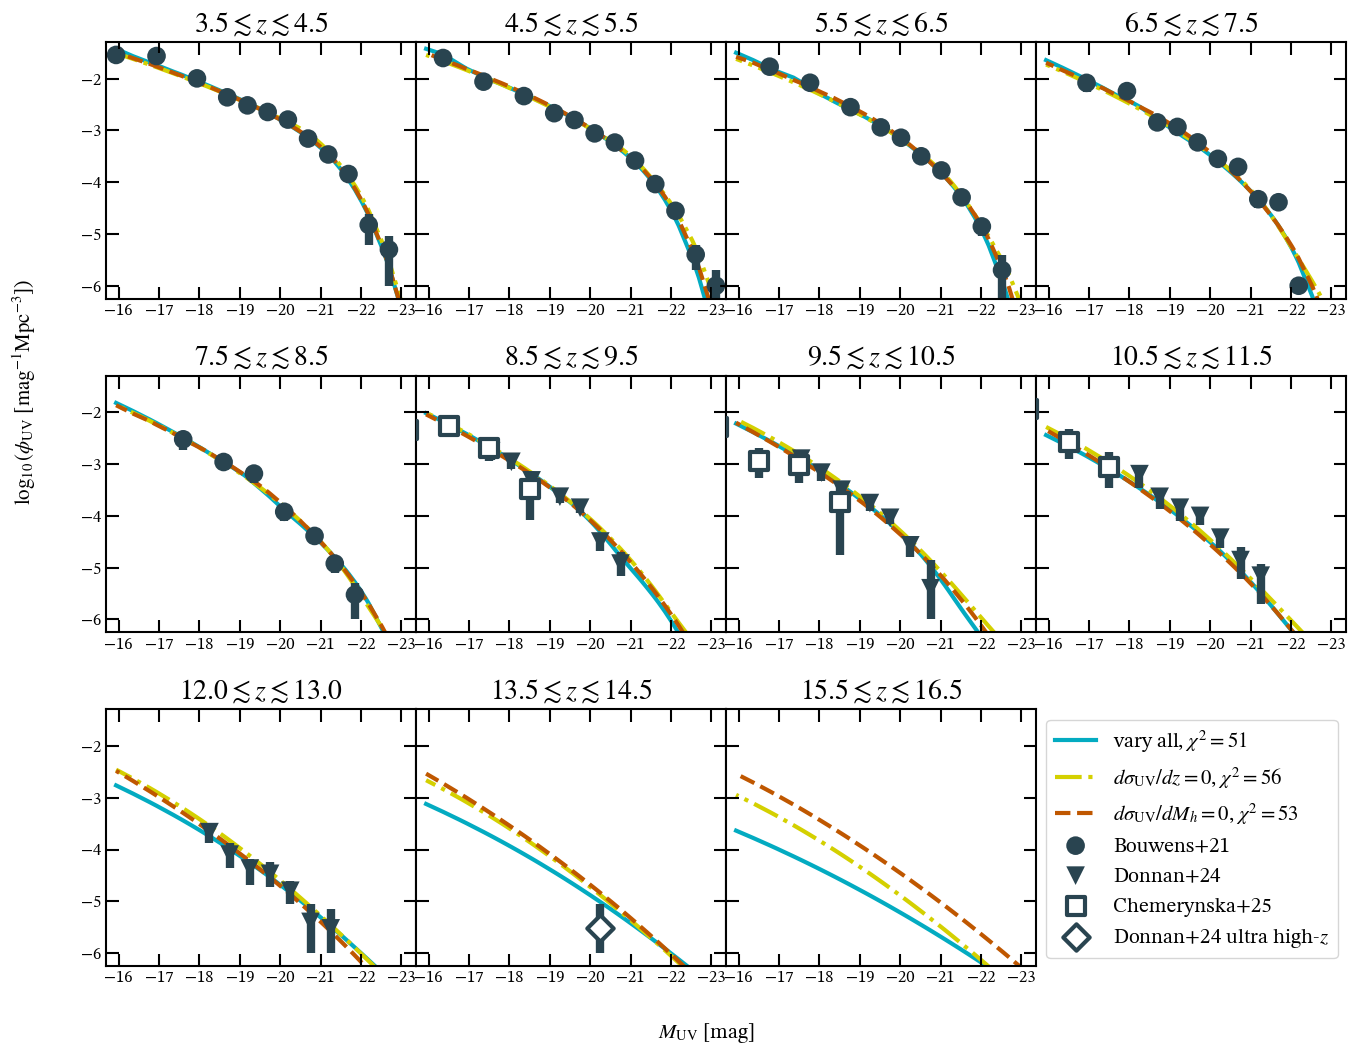

In [241]:
comparison_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [high_z_fit, no_z_ev, no_m_ev], 
                               comparison_labels = ['vary all', r'$d\sigma_{\rm{UV}}/dz = 0$', r'$d\sigma_{\rm{UV}}/dM_{h} = 0$'], 
                               title = '', z_plot = [4, 5, 6, 7, 8, 9, 10, 11, 12.5, 14, 16], ncols = 4)

In [242]:
comparison_fig.savefig('/Users/eb35267/Desktop/code/home/figures/add_extra_data.png', bbox_inches='tight')

In [7]:
param_labels = my_UVLF.param_data['label'].values[my_UVLF.param_data['fit'].values.astype(bool)]
table_comparison = eplots.make_table([best_fit, other_fit], param_labels, 
                                     fit_labels = ['best fit', 'alternative fit'],  
                                     bounds = [None, None])

In [ ]:
#dfi.export(table_comparison, '/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/fit_comparison_table.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

In [282]:
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}, 
                                 'dsigdz':{'fit':False, 'value':0}})
my_UVLF_no_z = eMCMC.UVLF(sorted_data, params)
walkers_no_z, _, _, _ = my_UVLF_no_z.get_fit(backend_file = '/Users/eb35267/Desktop/code/home/figures/force_dsigdz_0/samples.h5')

In [283]:
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}, 
                                 'dsigdlogM':{'fit':False, 'value':0}})
my_UVLF_no_M = eMCMC.UVLF(sorted_data, params)
walkers_no_M, _, _, _ = my_UVLF_no_M.get_fit(backend_file = '/Users/eb35267/Desktop/code/home/figures/force_dsigdMh_0/samples.h5')

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_58186/1748261573.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[i].set_title(my_UVLF_no_M.param_data['label'][my_UVLF_no_M.fit][i])


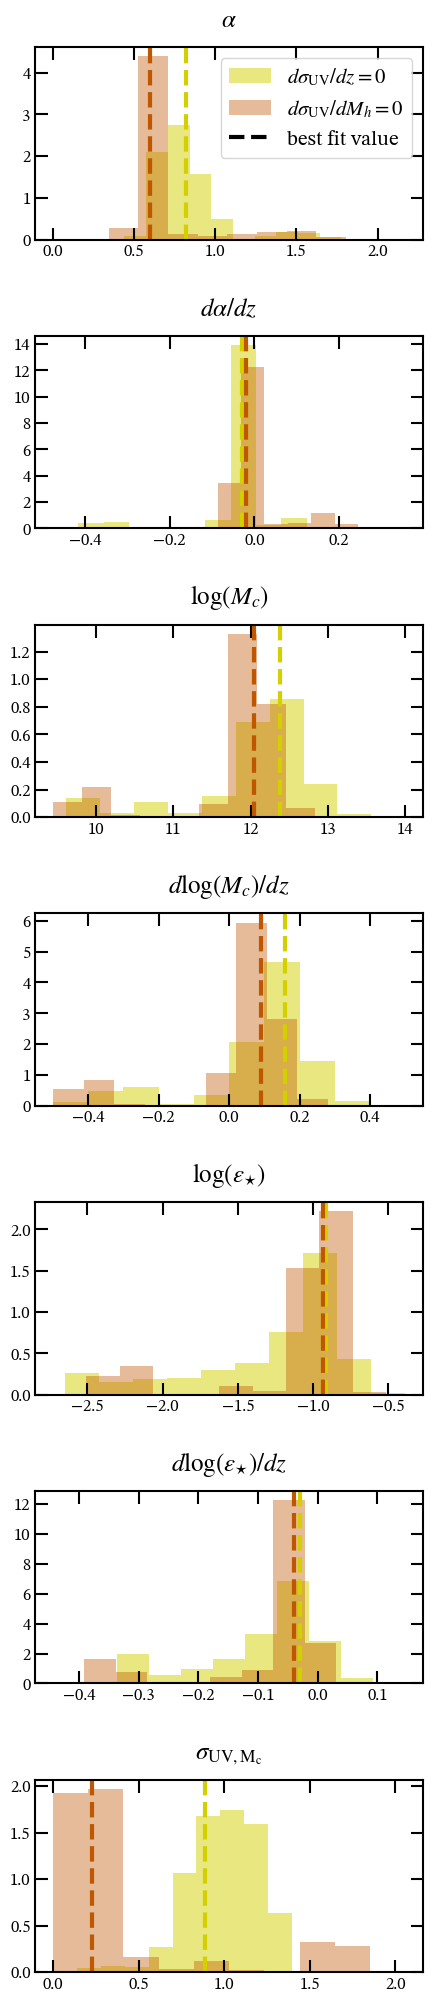

In [284]:
n = len(walkers_no_M[0][:-1])
fig, ax = plt.subplots(n, 1)
fig.set_size_inches(5, 25)
plt.subplots_adjust(hspace = 0.5)
alpha = 0.4
for i in range(n):
    ax[i].hist(walkers_no_z[:,i], alpha=alpha+0.1, density = True, label = r'$d\sigma_{\rm{UV}}/dz = 0$', color = eplots.yellow)
    ax[i].axvline(no_z_ev[i], color = eplots.yellow, ls = 'dashed')
    ax[i].hist(walkers_no_M[:,i], alpha = alpha, density = True, label = r'$d\sigma_{\rm{UV}}/dM_{h} = 0$', color = eplots.orange)
    ax[i].axvline(no_m_ev[i], color = eplots.orange, ls = 'dashed')
    ax[i].set_title(my_UVLF_no_M.param_data['label'][my_UVLF_no_M.fit][i])

ax[0].plot(0, 0, ls = 'dashed', color = 'black', label = 'best fit value')

ax[0].legend()

In [285]:
fig.savefig('/Users/eb35267/Desktop/code/home/figures/posterior_comparison.png', bbox_inches = 'tight')

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_58186/2886184360.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_title(my_UVLF_no_z.param_data['label'][my_UVLF_no_z.fit][-1])


Text(0.5, 1.0, '$d\\sigma_{\\rm{UV}}/d\\log(M_{h})$')

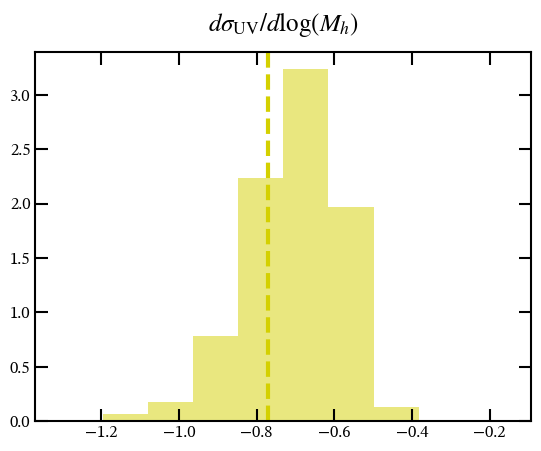

In [286]:
fig, ax = plt.subplots()
ax.hist(walkers_no_z[:,-1], density = True, color = eplots.yellow, alpha = 0.5)
ax.axvline(no_z_ev[-1], color = eplots.yellow, ls = '--')
ax.set_title(my_UVLF_no_z.param_data['label'][my_UVLF_no_z.fit][-1])

In [287]:
fig.savefig('/Users/eb35267/Desktop/code/home/figures/no_z_dsigdMh.png', bbox_inches = 'tight')

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_58186/295354530.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_title(my_UVLF_no_M.param_data['label'][my_UVLF_no_M.fit][-1])


Text(0.5, 1.0, '$d\\sigma_{\\rm{UV}}/dz$')

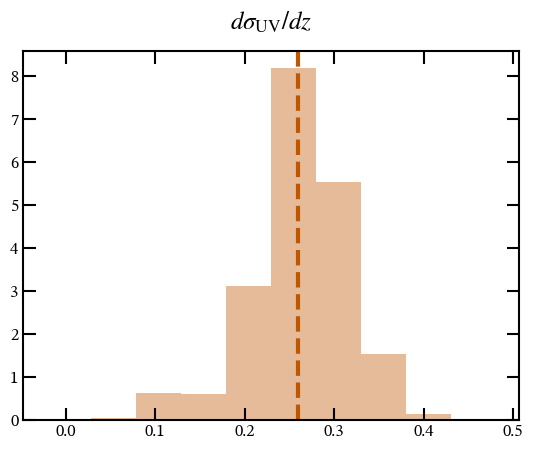

In [289]:
fig, ax = plt.subplots()
ax.hist(walkers_no_M[:,-1], density = True, color = eplots.orange, alpha = 0.4)
ax.axvline(no_m_ev[-2], color = eplots.orange, ls = '--')
ax.set_title(my_UVLF_no_M.param_data['label'][my_UVLF_no_M.fit][-1])

In [290]:
fig.savefig('/Users/eb35267/Desktop/code/home/figures/no_M_dsigdz.png', bbox_inches = 'tight')

# SFE($M_h$) for different $z$

In [ ]:
def plot_sfe_evolution(my_UVLF, param_values, Mhtab, zmax, steps = 100):
    
    fig, ax = plt.subplots()
    zs = np.linspace(0, zmax, steps)

    cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)

    for Mh in Mhtab:
        SFEs = np.zeros(steps)
        Mz = cosmo_calc.calc_Mz(zs, Mh, my_UVLF)
        for i, (z, Mz_i) in enumerate(zip(zs, Mz)):
            params = my_UVLF.time_evolution(param_values, z)
            Astro_Parameters = my_UVLF.param_wrapper(params)
                           
            SFEs[i] = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
                Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mz_i)
        
        frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
        color = cmap(frac)
        ax.plot(zs, SFEs, color = color, ls = '-')

    # Color bar things:
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$ at $z=0$')

    ax.set_ylabel(r'$f_{\star} = \dot{M}_{\star} / \dot{M}_{\rm{gas}}$')
    ax.set_xlabel('redshift')
    ax.set_yscale('log')

    return fig

In [62]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

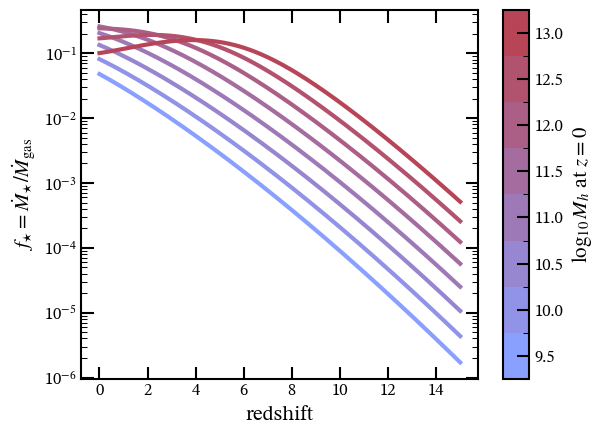

In [63]:
sfe_fig = eplots.sfe_over_time(my_UVLF, best_fit)

In [ ]:
#sfe_fig.savefig('/Users/eb35267/Desktop/code/figures/all_data_test/sfe_over_redshift.png', bbox_inches='tight')

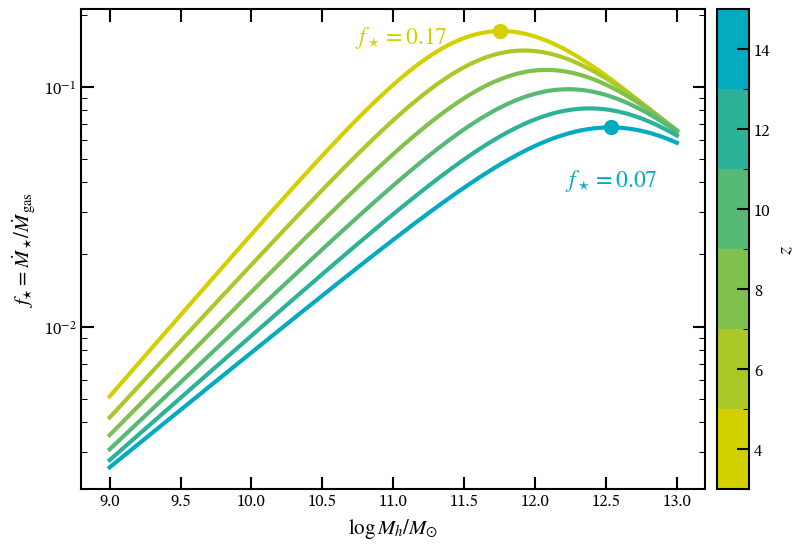

In [268]:
sfe_fig_2 = eplots.sfe_shape_diff_z(my_UVLF, no_m_ev, Mhtab = np.linspace(9, 13, 200), 
                             zs =np.arange(4, 16, 2), id_max = True)

In [269]:
sfe_fig_2.savefig('/Users/eb35267/Desktop/code/home/figures/force_dsigdMh_0/sfe_over_z_id_max.png', bbox_inches='tight')

In [37]:
10**(my_UVLF.time_evolution(best_fit, 9)[3])

0.0933254300796991

In [39]:
my_UVLF.time_evolution(best_fit, 9)

[0.92, -0.54, 11.71, -1.03, array([1.2 , 0.77, 0.34, 0.3 , 0.3 ])]

In [ ]:
#sfe_fig_2.savefig('/Users/eb35267/Desktop/figures/Committee_25/sfe.png', bbox_inches='tight')

In [126]:
my_UVLF.data[0]

[4.0,
 0.5,
 array([-22.69, -22.19, -21.69, -21.19, -20.69, -20.19, -19.69, -19.19,
        -18.69, -17.94, -16.94, -15.94]),
 array([5.000e-06, 1.500e-05, 1.440e-04, 3.440e-04, 6.980e-04, 1.624e-03,
        2.276e-03, 3.056e-03, 4.371e-03, 1.016e-02, 2.742e-02, 2.882e-02]),
 array([4.00e-06, 9.00e-06, 2.20e-05, 3.80e-05, 6.80e-05, 1.31e-04,
        1.99e-04, 3.88e-04, 6.89e-04, 9.20e-04, 3.44e-03, 8.74e-03]),
 array([4.00e-06, 9.00e-06, 2.20e-05, 3.80e-05, 6.80e-05, 1.31e-04,
        1.99e-04, 3.88e-04, 6.89e-04, 9.20e-04, 3.44e-03, 8.74e-03]),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])]

# P(Mh|MUV)

In [ ]:
def PMh(param_values, my_UVLF, MUV_range, z_range):

    fig, ax = plt.subplots(len(z_range), 1, sharex = True) 
    if len(z_range) == 1:
        ax = [ax]
    fig.set_size_inches(6, 3*len(z_range))
    plt.subplots_adjust(hspace = 0)
    
    # Define colormap
    cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.orange, eplots.navy], MUV_range)

    # Define grid of halo masses
    Mhtab = np.logspace(8, 14, 200)
    my_UVLF.HMFintclass.Mhtab = Mhtab

    for i, z in enumerate(z_range):
        # Get the HMF at that redshift
        hmf = my_UVLF.HMFintclass.HMF_int(Mhtab, z)
        # Integtrate over the HMF
        hmf_integral = trapz(hmf, Mhtab)

        # Get the time-evolving parameters
        params = my_UVLF.time_evolution(param_values, z) # Calculate how parameters evolve with redshift
        astroparams = my_UVLF.param_wrapper(params)# Get the parameters in the right format for use with zeus21
        
        # Use the parameter values to get MUV_bar at a given Mh
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, Mhtab, z, z) # Calculate SFR
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV) # Use SFR to calculate average MUV
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX) # Make sure that MUV doesn't exceed a set value

        for MUV in MUV_range:
            probabilities = np.zeros_like(Mhtab)

            # Calculate probability for each pair of Mh, MUV
            for j, (sigUV, MUV_bar, Mh) in enumerate(zip(params[-1], MUVbarlist, Mhtab)): # Plot different color-coded Gaussians for different halo masses
                
                # Calculate Gaussian based on MUV_bar & sig_UV
                PMUVgivenMh = (1/(sigUV * np.sqrt(2*np.pi)))*np.exp(-(MUV-MUV_bar)**2/(2*sigUV**2)) 

                # PMh = HMF(Mh) / integral(HMF)
                PMh = my_UVLF.HMFintclass.HMF_int(Mh, z) / hmf_integral
                
                probabilities[j] =  PMUVgivenMh * PMh
                
            # Get the color based on MUV
            frac = ((MUV - min(MUV_range)) / (max(MUV_range) - min(MUV_range)))
            color = cmap(frac)
            
            # Normalize the PDF
            norm = trapz(probabilities, np.log10(Mhtab))
            ax[i].plot(np.log10(Mhtab), probabilities/norm, color = color, ls = '-')
        
        # Make invisible line for legend purposes
        ax[i].text(0.91, 0.87, f'$z={z}$', transform = ax[i].transAxes, ha = 'center', va = 'center')
        ax[i].set_ylim(1e-10, 10)
        ax[i].set_yscale('log')

    # Color bar things:
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=MUV_range, aspect = 7*len(z_range))
    cbar.set_label(r'$M_{\rm{UV}}$')

    fig.supylabel(r'$p(M_h|M_{\rm{UV}})$', fontsize = 17)
    ax[-1].set_xlabel(r'$\log_{10} M_{h} / M_\odot$', fontsize = 17)


    return fig


In [826]:
best_fit = [0.74, -0.01, -0.26, 0.13, 12.39, 0.14, -0.97, -0.05, 0.94, 0.07, -0.61]

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_17709/3057280774.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probabilities[j] =  PMUVgivenMh * PMh


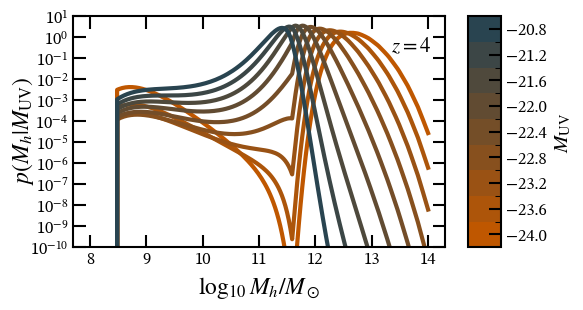

In [829]:
fig = PMh(best_fit, my_UVLF, np.arange(-24, -20.5, 0.4), [4])

In [ ]:
#fig.savefig('/Users/eb35267/Desktop/code/home/figures/PMh_z4.png', bbox_inches='tight')

# Push SFE as high as it can go

In [16]:
backend_file = '/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/samples.h5'

In [17]:
samples, best_fit, _, labels = my_UVLF.get_fit(backend_file)

AttributeError: You must run the sampler with 'store == True' before accessing the results

In [230]:
def get_sigma_ellipse(samples, n_sigma):
    x,y = samples[:,0], samples[:,1]
    mean2d = [x.mean(), y.mean()]
    covariance = np.cov(x,y)

    # Get the length & direction of the axes of the ellipse describing the covariance between x & y
    length, dir_vec = np.linalg.eigh(C)
    # Get the index corresponding to the major axis (longer than the minor axis)
    maj_idx = np.argmax(length)
    maj_length, maj_vec = np.sqrt(length[maj_idx]), dir_vec[maj_idx] # sqrt(length) corresponds to 1 sigma from the mean
    maj_ax_endpoints = [mean2d - (n_sigma*maj_length*maj_vec), mean2d + (n_sigma*maj_length*maj_vec)]

    return maj_ax_endpoints
    
    

In [233]:
maj_ax_endpoints = get_sigma_ellipse(samples[:,4:6], n_sigma = 3)

In [234]:
maj_ax_endpoints

[array([-0.71398897,  0.02397716]), array([-1.15994919, -0.10750175])]

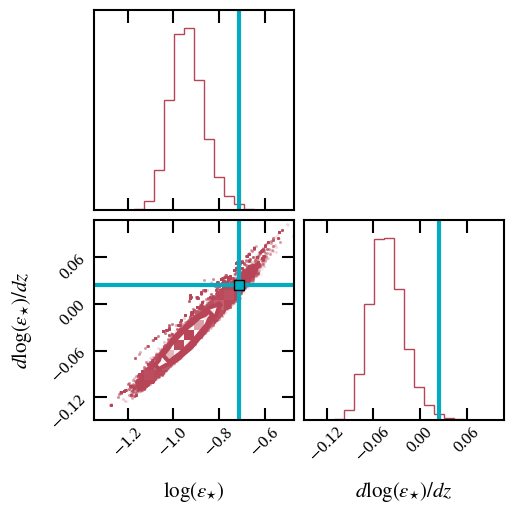

In [235]:
corner = eplots.make_corner(my_UVLF, backend_file = backend_file, excluded_params = ['dalphadz', 'logMc', 'dlogMcdz', 'sig', 'alpha', 'dsigdz', 'dsigdlogM']
                            ,true_vals = maj_ax_endpoints[0])

In [ ]:
#corner.savefig('/Users/eb35267/Desktop/code/home/figures/high_sfe_limit/best_fit.png', bbox_inches='tight')

In [25]:
my_UVLF.param_data

,fit,value,lower,upper,label
alpha,True,0.6,0,4,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,False,-0.54,-3,0,$\beta$
dbetadz,False,0,-1,1.5,$d\beta/dz$
logMc,True,12,9,16,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-4.5,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.5,1,$d\sigma_{\rm{UV}}/dz$


In [41]:
test_fit = [0.87, 0, 11.71, 0, -0.71, 0, 0.17, 0, 0]

In [61]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

Text(0.5, 1.0, 'best fit')

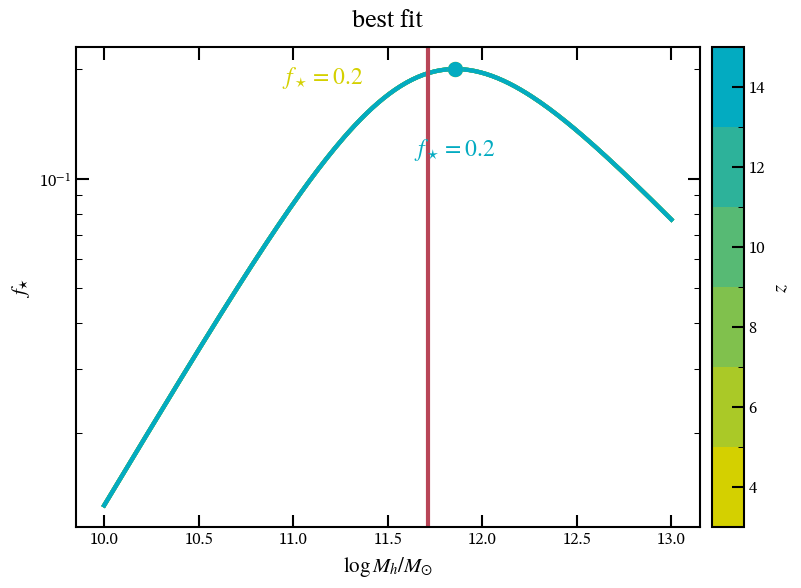

In [62]:
sfe_high, sfe_ax = eplots.sfe_shape_diff_z(my_UVLF, param_values = test_fit, zs = np.arange(4, 16, 2), id_max = True)
sfe_ax.axvline(11.71)
sfe_ax.set_title(r'best fit')

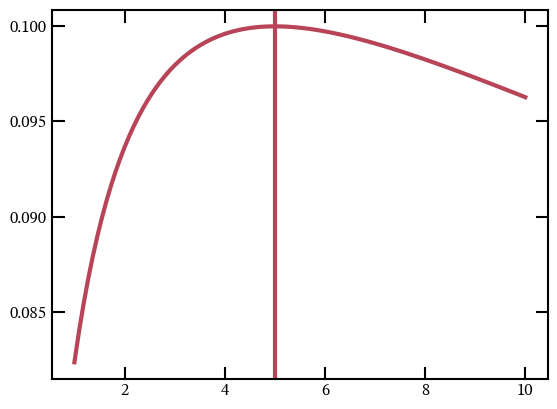

In [88]:
x = np.linspace(1, 10, 100)
y = 0.2/(((x/5)**(-0.4)) + ((x/5)**(0.4)))

plt.plot(x, y)
plt.axvline(5)

In [ ]:
#sfe_high.savefig('/Users/eb35267/Desktop/code/home/figures/high_sfe_limit/best_fit_sfe.png', bbox_inches='tight')

# Predictions

In [ ]:
def make_prediction(my_UVLF, z_plot, comparison_fits = [], comparison_labels = [], 
                      ncols = 3, title = 'UVLF prediction'):
    
    if type(z_plot) == list:
        z_plot = np.array(z_plot)
    
    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the saved data

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    
    # Adjust size & spacing
    fig.set_size_inches(3*ncols, 3*math.ceil((nz+1)/ncols))
    plt.subplots_adjust(wspace = 0, hspace = 0.3)

    # Set the same y limits for all the plots
    ylo, yhi = np.log10(min([min(dat[3]) for dat in my_UVLF.data]))-0.25, np.log10(max([max(dat[3]) for dat in my_UVLF.data]))+0.25 

    # Get the x grid to evaluate the UVLF over
    plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5] # Use the lowest redshift MUV centers & bins as the grid to calculate the
                                                                # theoretical UVLF on

    zerr = 0.5
    for i, zdat in enumerate(z_plot): 
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])

        # Plot comparison fits
        for fit, label, color, ls in zip(comparison_fits, comparison_labels, [eplots.turquoise, eplots.yellow, eplots.orange, eplots.green], 
                                        ['solid', 'dashdot', 'dashed', 'dotted']):
            ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr, fit)), color = color, 
                       label = fr'{label}', linestyle = ls, zorder = 1)

        ax.invert_xaxis()
        ax.set_ylim(ylo, yhi)
        ax.set_xlim(np.max(plot_xdat)+0.25, np.min(plot_xdat)-0.25)
        ax.set_title(fr'$z \simeq {round(zdat, 1)}$', fontsize = 16, pad = 8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                       # axis labels
        ax.axes.yaxis.set_ticklabels([])

        idx = np.where(data_z==zdat)[0]
        if len(idx) > 0:
            zbin = my_UVLF.sorted_data[idx[0]]
            for dat, fmt in zip(zbin, ['o', 'v', 's', 'D', '^']):
                _, _, xdat, ydat, yerr_upper, yerr_lower, xerr = edata.decompose(dat)
                ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat[7], c = eplots.navy, s = 180)
                ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', 
                        colors = eplots.navy, linewidth =6)
                
            handles, labels = ax.get_legend_handles_labels() # Grab handles/labels for the legend

    i += 1
    
    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'
    if math.ceil((nz+1)/ncols) > 1: # This means that there's more than one row of plots
        if i%ncols==0:
            fig.text(0.065, 0.5, ylabel, rotation = 'vertical')
            fig.text(0.5, 0.27, xlabel, ha = 'center')
        elif i%ncols == 1:
            fig.supylabel(ylabel, x = 0.05)
            fig.supxlabel(xlabel, y = 0.07)
        else:
            print('here')
            fig.supylabel(ylabel, x = 0.05)
            fig.supxlabel(xlabel, y = 0)
        fig.text(.5, 0.95, title, ha = 'center', fontsize = 20)
    else:
        if nz == 1:
            ax.set_ylabel(ylabel)
            ax.set_xlabel(xlabel)
            ax.set_title(title)
        else:
            fig.text(0.065, 0.225, ylabel, rotation = 'vertical')
            fig.text(0.375, 0, xlabel, ha = 'center')
            fig.text(0.375, 1, title, ha = 'center', fontsize = 20)

    # Put legend outside the last axis
    fig_ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
    fig_ax.axis("off")  
    fig_ax.legend(handles, labels, loc='center left')
    
    return fig


In [151]:
from collections import OrderedDict
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, title = 'UVLF data vs. MCMC fit', burn_in = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        include_zs [list of floats]: redshifts to plot, or leave as None if you want to plot all of them
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        title [str]: overarching title of the plot
        burn_in [int]: number of samples to discard as burnin
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        idxs = np.concatenate([np.where(np.abs(data_z - z) < zerr)[0] for z, zerr in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
        assert len(z_plot) == len(z_errs), 'The given redshifts to plot and the given redshift errors must be the same length'
    
    if type(z_plot) == list:
        z_plot = np.array(z_plot)
    if type(z_errs) == list:
        z_errs = np.array(z_errs)


    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    
    # Adjust size & spacing
    fig.set_size_inches(4*ncols, 4*math.ceil((nz+1)/ncols))
    plt.subplots_adjust(wspace = 0, hspace = 0.3)

    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    ylo, yhi = np.log10(min([min(dat[3]) for dat in my_UVLF.data]))-0.25, np.log10(max([max(dat[3]) for dat in my_UVLF.data]))+0.25 

    # Get the biggest possible grid of x data to plot over
    plot_xdat, inds = np.unique(np.concatenate([data[2] for data in my_UVLF.data]), return_index = True) 
    # Get the corresponding x error
    plot_xerr = np.concatenate([data[6] for data in my_UVLF.data])[inds]

    axs = []
    for i, (z, zerr) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(z,zerr, plot_xdat, plot_xerr,sample)), alpha=6/max(nsamples, 6), 
                           color = red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)
            ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(z, zerr, plot_xdat, plot_xerr, best_fit)), color = red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$', lw = 5)
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = 'sampled fits', linestyle = '-', lw = 5) # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, label, color, ls in zip(comparison_fits, chi2_comparison, comparison_labels, 
                                                   [eplots.turquoise, eplots.yellow, eplots.orange, eplots.green], 
                                        ['solid', 'dashdot', 'dashed', 'dotted']):
            ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(z,zerr,plot_xdat,plot_xerr, fit)), color = color, 
                       label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$', linestyle = ls, zorder = 1)
        
        # Plot data
        idx = np.where(np.abs(data_z - z) <= zerr)[0]
        if len(idx) > 0:
            zbin = my_UVLF.sorted_data[idx[0]]
            for dat, fmt in zip(zbin, ['o', 'v', 's', 'D', '^']):
                _, _, xdat, ydat, yerr_upper, yerr_lower, xerr = edata.decompose(dat)
                ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat[7], c = eplots.navy, s = 180)
                ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', 
                        colors = eplots.navy, linewidth =6)

        ax.invert_xaxis()
        ax.set_ylim(ylo, yhi)
        ax.set_xlim(np.max(plot_xdat)+0.25, np.min(plot_xdat)-0.25)
        ax.set_title(fr'${round(z-zerr, 1)} \lesssim z \lesssim {round(z+zerr, 1)}$', fontsize = 20, pad = 8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                       # axis labels
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                       # axis labels
        if i%ncols != 0:
            ax.axes.yaxis.set_ticklabels([])

    # Create legend
    legend = OrderedDict() # Avoids duplicates & ensures that the legend is in order of what people will see first
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            legend.setdefault(l, h)

    handles, labels = list(legend.values()), list(legend.keys())


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'
    if math.ceil((nz+1)/ncols) > 1: # This means that there's more than one row of plots
        if (i+1)%ncols==0:
            fig.text(0.065, 0.5, ylabel, rotation = 'vertical')
            fig.text(0.5, 0.35, xlabel, ha = 'center')
        elif (i+1)%ncols == 1:
            fig.supylabel(ylabel, x = 0.05)
            fig.supxlabel(xlabel, y = 0.03)
        else:
            fig.supylabel(ylabel, x = 0.05)
            fig.supxlabel(xlabel, y = -0.03)
    else:
        if nz == 1:
            ax.set_ylabel(ylabel)
            ax.set_xlabel(xlabel)
        else:
            fig.text(0.065, 0.225, ylabel, rotation = 'vertical')
            fig.text(0.375, 0, xlabel, ha = 'center')

    # Put legend outside the last axis
    fig_ax = fig.add_subplot(gs[math.floor((i+1)/ncols), (i+1)%ncols])
    fig_ax.axis("off")  
    fig_ax.legend(handles, labels, loc='upper left')

    return fig

In [152]:
importlib.reload(eMCMC)
my_UVLF = eMCMC.UVLF(sorted_data, params)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


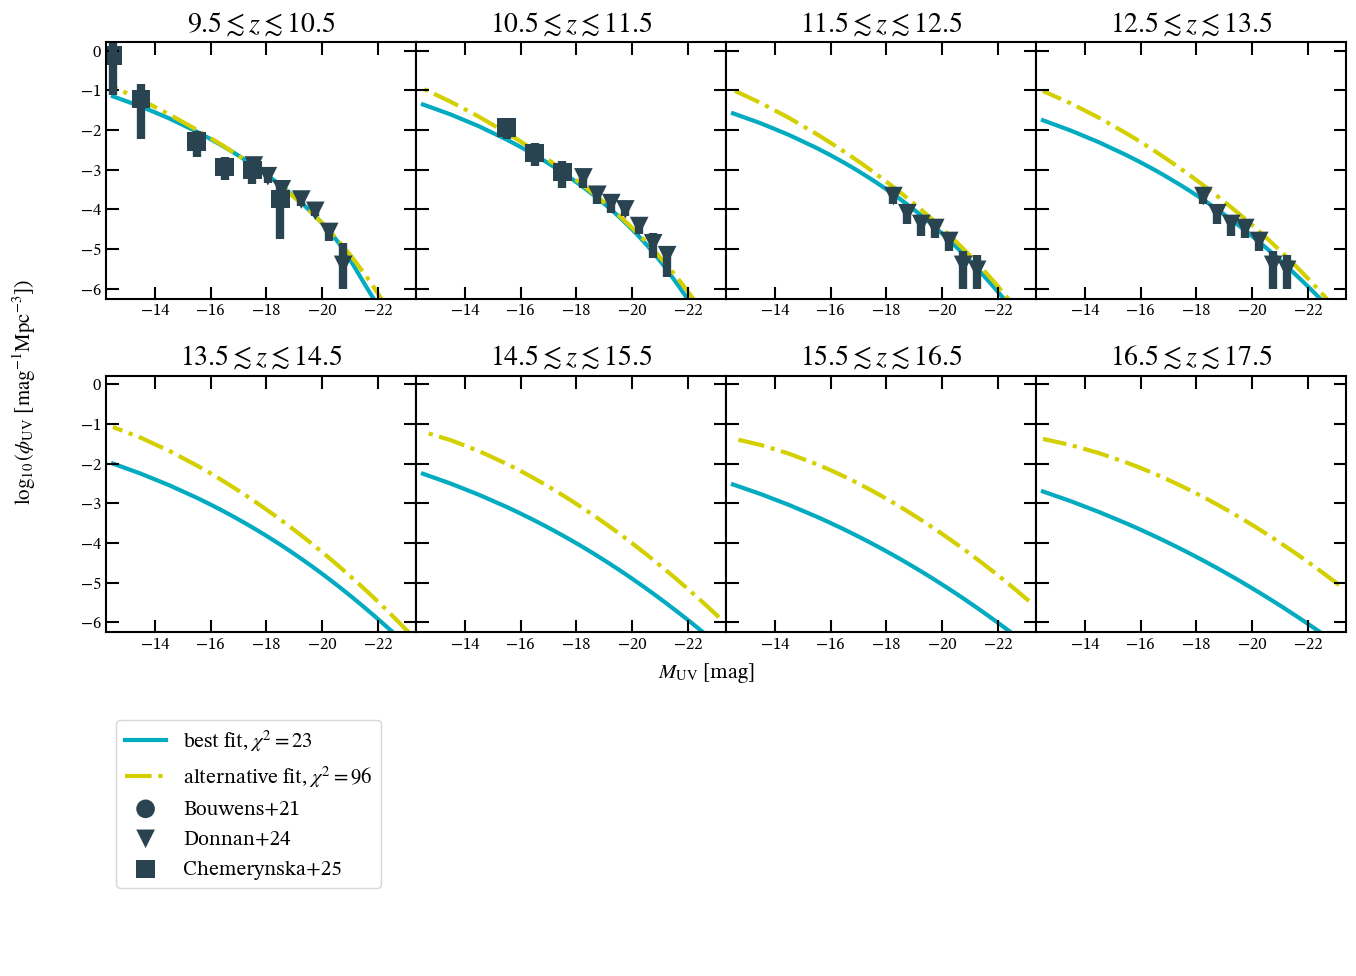

In [154]:
z_plot = np.array([10, 11, 12, 13, 14, 15, 16, 17])
z_errs = np.full(len(z_plot), 0.5)
fig = evolving_UVLF_fit(my_UVLF, z_plot = z_plot, z_errs = z_errs, comparison_fits = [best_fit, other_fit], 
                               comparison_labels = [r'best fit', 'alternative fit'], ncols = 4, plot_from_chain = False)

In [ ]:
my_UVLF.CosmoP

In [162]:
omega_b = .022
omega_c = .120
h = 0.678

In [165]:
Omega_b = omega_b/h**2
Omega_m = (omega_b+omega_c)/h**2

In [166]:
print(Omega_b, Omega_m)

0.047858963983954186 0.3089078584418861


In [ ]:
zdat, zerr = zbin[0][0], np.concatenate([dat[1] for dat in zbin])[0]

In [1]:
print('hello GitHub')

hello GitHub


# Gelli+24 comparison

In [ ]:
def sigma_Mh(my_UVLF, param_values, zs = None):
    
    fig = plt.figure(figsize=(8, 6))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if zs is None:
        zs = np.arange(4, 16, 2)

    cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)
    
    Mhtab = np.log10(my_UVLF.HMFintclass.Mhtab)
    indices = np.where((Mhtab >= 8.5) & (Mhtab <= 12))[0]
    Mhtab = Mhtab[indices]
    
    for z in zs:
        sig_array = my_UVLF.time_evolution(param_values, z)[-1][indices]

        frac = (z - min(zs)) / (max(zs) - min(zs))
        color = cmap(frac)
        ax.plot(Mhtab, sig_array, ls = '-', color = color)

    # Compare to the Gelli+24 parameterization
    sig_gelli = (-0.34 * Mhtab) + 4.5
    ax.plot(Mhtab, sig_gelli, linestyle = '--', color = eplots.red, label = 'Gelli+24')

    # Color bar things:
    cax = fig.add_axes(cax_rect)
    cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
    cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

    ax.legend()
    
    return fig

In [99]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

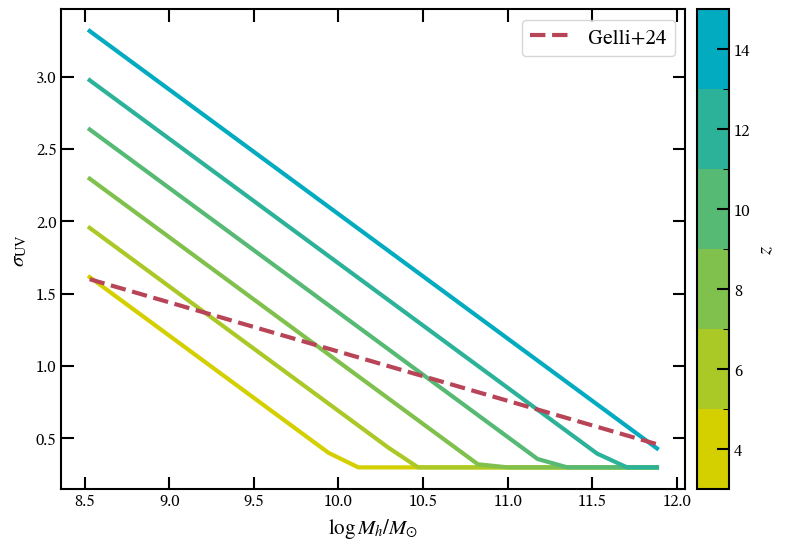

In [102]:
sigMh_fig = eplots.sigma_Mh(my_UVLF, best_fit)

In [103]:
sigMh_fig.savefig('/Users/eb35267/Desktop/code/home/figures/sigMhvsgelli.png', bbox_inches='tight')

# See one UVLF fit over time

In [307]:
def UVLF_over_time(my_UVLF, fits, labels, z_plot = None, z_errs = None):

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data

    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < zerr)[0] for z, zerr in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]

    fig, axs = plt.subplots(1, len(fits))
    fig.set_size_inches(5*len(fits), 4)
    plt.subplots_adjust(wspace = 0.1)

    # Create custom colorbar
    cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.turquoise, eplots.yellow], z_plot)

    # Get the biggest possible grid of x data to plot over
    plot_xdat, xdat_inds = np.unique(np.concatenate([data[2] for data in my_UVLF.data]), return_index = True) 
    # Get the corresponding x error
    plot_xerr = np.concatenate([data[6] for data in my_UVLF.data])[xdat_inds]

    for fit, label, ax in zip(fits, labels, axs):
        for (z, zerr) in zip(z_plot, z_errs): 
            # Get color based on redshift
            frac = (z - min(z_plot)) / (max(z_plot) - min(z_plot)) 
            color = cmap(frac)
            ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(z,zerr,plot_xdat,plot_xerr, fit)), color = color, linestyle = '-', zorder = 1)
            
        
        ax.invert_xaxis()
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                        # axis labels                                                                            
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                        # axis labels    
        ax.set_title(label)                                                                    


        # Text & labels
        xlabel = r'$M_{\rm{UV}}$ [mag]'
        ax.set_xlabel(xlabel)

    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    axs[0].set_ylabel(ylabel)

    # Colorbar things
    cax_rect = [.92, 0.095, 0.025, 0.80]
    cax = fig.add_axes(cax_rect)
    cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=z_plot, aspect = 14)
    cbar.set_label('Redshift')

    return fig

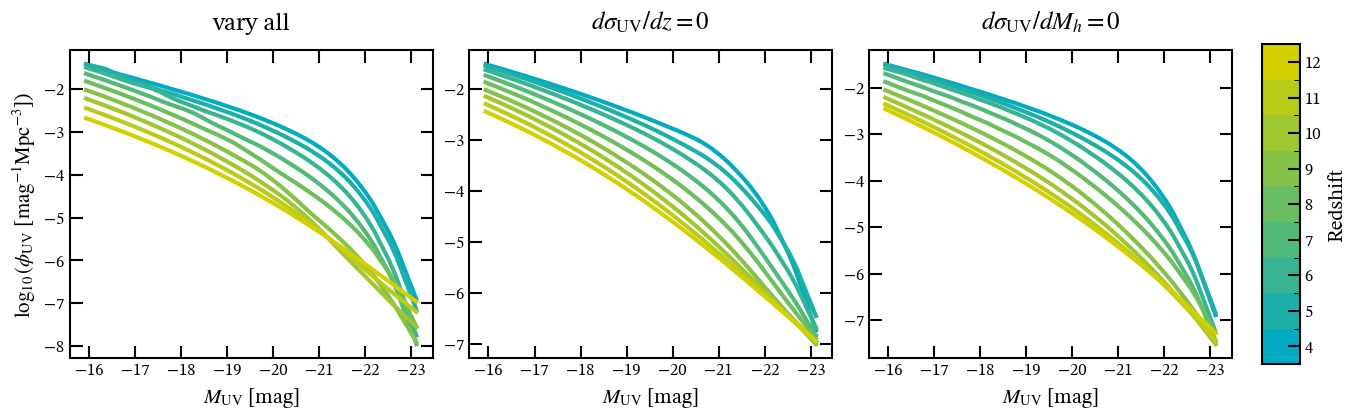

In [342]:
z_plot = np.arange(4, 13, 1)
z_errs = np.full_like(z_plot, 0.5)
all_z_one_plot = UVLF_over_time(my_UVLF, [high_z_fit, no_z_ev, no_m_ev], ['vary all', r'$d\sigma_{\rm{UV}}/dz = 0$', r'$d\sigma_{\rm{UV}}/dM_{h} = 0$'], z_plot, z_errs)

In [351]:
.57+1.84

2.41

In [344]:
my_UVLF.time_evolution(no_m_ev, 12)

[0.52,
 -0.54,
 12.399999999999999,
 -1.09,
 array([1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04,
        1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04,
        1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 1.27e+00,
        1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00,
        1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00,
        1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00,
        1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00,
        1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00,
        1.27e+00, 1.27e+00, 1.27e+00, 1.27e+00])]

In [311]:
all_z_one_plot.savefig('/Users/eb35267/Desktop/code/home/figures/comparison_all_z_one_plot.png', bbox_inches = 'tight')

# Old stuff

In [89]:
param_data = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 
                                     'dbetadz': {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 
                                     'dlogMcdz':{'fit':False, 'value':0}})

In [144]:
my_UVLF = eMCMC.UVLF(sorted_data, param_data)

In [152]:
def sfe_shape_diff_fits(fits, fit_labels, my_UVLF, Mhtab):

    fig, ax = plt.subplots()
    
    for fit, fit_label in zip(fits, fit_labels):
        params = my_UVLF.time_evolution(fit, 0)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        SFEs = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, 0, 10**Mhtab)
        
        ax.plot(Mhtab, SFEs, label = fit_label)

    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\dot{M}_{\star} / f_b\dot{M}_h$')
    ax.legend()
    ax.set_yscale('log')
        
        
    return fig

In [153]:
fit_456 = [0.71, -0.54, 11.79, -0.81, 0.07, -0.61]
fit_789 = [0.78, -0.54, 11.79, -0.99, 0.23, -0.61]
fit_10plus = [0.3, -0.54, 11.79, -3.09, 1.4, -0.52]

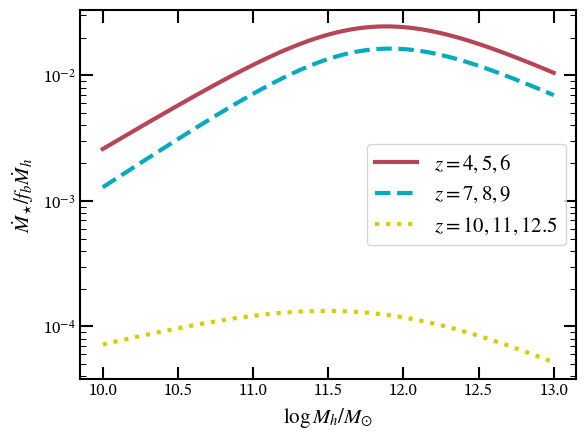

In [189]:
fig = sfe_shape_diff_fits([fit_456, fit_789, fit_10plus], [r'$z=4, 5, 6$', r'$z= 7, 8, 9$', r'$z=10, 11, 12.5$'],
                          my_UVLF, Mhtab = np.linspace(10, 13, 200))

In [190]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/sfe_comparison_narrowed_fixed.png', bbox_inches = 'tight')

In [213]:
def compare_MUV_distribution(my_UVLF, fits, fit_labels, Mhtab):
    fig, ax = plt.subplots()
    MUV_range = np.linspace(-15, -22, 500)
    ax.invert_xaxis()
    
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.red, eplots.navy])
    dM = Mhtab[1]-Mhtab[0] # Separation between each halo mass
    norm = BoundaryNorm(np.arange(min(Mhtab), max(Mhtab)+dM, dM), cmap.N)
    
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab 
    
    for fit, fit_label, ls in zip(fits, fit_labels, ['-', (0, (5, 1))]):
        #total_prob = np.zeros_like(MUV_range)
        params = my_UVLF.time_evolution(fit, 0)
        astroparams = my_UVLF.param_wrapper(params)
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, 10**Mhtab, 0, 0)
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV)
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX)

        ax.plot(MUV_range[0], 0, ls = ls, color = 'black', label = fit_label) # Make invisible line for the legend purposes


        for sigUV, MUV_bar, Mh in zip(params[-1], MUVbarlist, Mhtab):
            frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
            color = cmap(frac)
            #prob = gaussian(MUV_range, sigUV, MUV_bar)
            #total_prob += prob
            ax.plot(MUV_range, gaussian(MUV_range, sigUV, MUV_bar), color = color, ls = ls)

        #plt.plot(MUV_range, total_prob, color = 'black', ls = ls)
        

    # Color bar things:
    boundaries = np.arange(Mhtab.min()-(dM/2), Mhtab.max()+(1.5*dM), dM) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$')

    ax.set_ylabel(r'$p(M_{\rm{UV}}|M_h)$')
    ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
    ax.legend()
    ax.set_yscale('log')
    ax.set_ylim(1e-20, 10)
    

    return fig

In [7]:
fig = compare_MUV_distribution(my_UVLF, [fit_456, fit_10plus], [r'$z=4, 5, 6$', r'$z=10, 11, 12.5$'], 
                               Mhtab = np.arange(7, 9, 0.5))

NameError: name 'compare_MUV_distribution' is not defined

In [215]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/MUV_comparison_narrowed_fixed.png')

In [38]:
from astropy import constants as c

In [53]:
(2.5*np.log10(25))-2.5

0.9948500216800942

In [57]:
(1.43e26)**(1/4)

3458071.8244567155

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


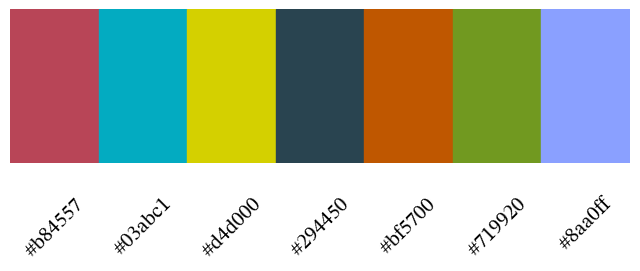

In [60]:
eplots.plot_colors()

In [8]:
np.sqrt(6.67e-20*4e30/(0.39*1.496e8))

67.62305895395347